🔄 Loading dataset...
Initial dataset: 23,078 rows

🔄 Initial removal of nulls and duplicates...
After initial cleaning: 23,078 rows
Train shape: (18462, 2) | Test shape: (4616, 2)

🔍 Running RandomizedSearchCV...
Fitting 3 folds for each of 25 candidates, totalling 75 fits

✅ Best Parameters:
{'rf__n_estimators': 400, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_depth': 20, 'rf__class_weight': 'balanced'}

📊 Classification Report:
                precision    recall  f1-score   support

         Major       0.79      0.79      0.79       585
         Minor       0.41      0.30      0.35        57
      Moderate       0.81      0.82      0.82      1290
No Interaction       0.96      0.94      0.95      2211
       Unknown       0.83      0.90      0.86       473

      accuracy                           0.88      4616
     macro avg       0.76      0.75      0.75      4616
  weighted avg       0.88      0.88      0.88      4616



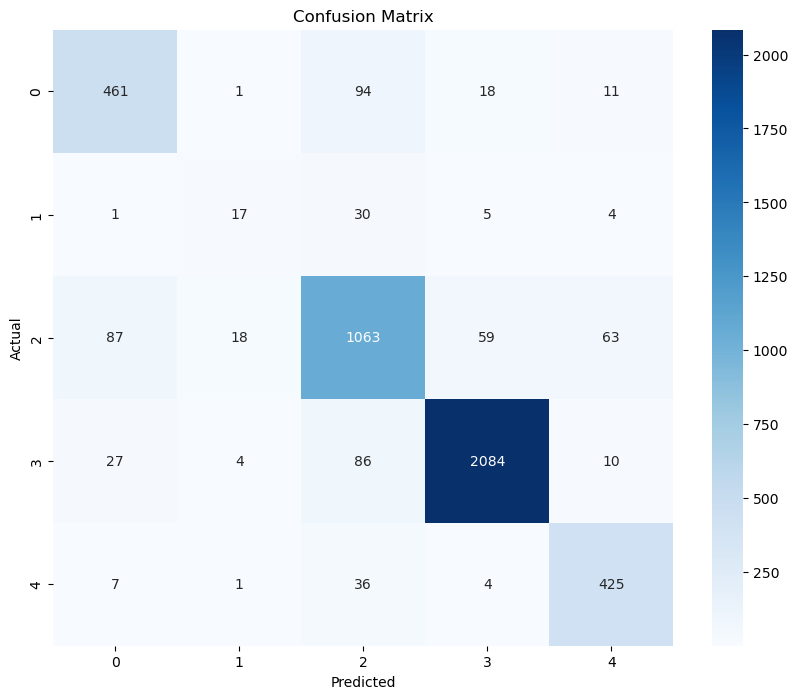

In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings('ignore')

# ====================== STEP 1: LOAD DATA ======================
print("🔄 Loading dataset...")

df = pd.read_csv('DDinter_with_negatives.csv')

# Normalize drug names
df['Drug_A'] = df['Drug_A'].str.lower().str.strip()
df['Drug_B'] = df['Drug_B'].str.lower().str.strip()

print(f"Initial dataset: {len(df):,} rows")

# ====================== STEP 3: INITIAL CLEANING ======================
print("\n🔄 Initial removal of nulls and duplicates...")
df = df.dropna(subset=['Drug_A', 'Drug_B', 'Level'])
df = df.drop_duplicates()
print(f"After initial cleaning: {len(df):,} rows")

# ====================== STEP 4: SPLIT DATA ======================
X = df[['Drug_A', 'Drug_B']]
y = df['Level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

# ====================== STEP 7: PIPELINE ======================
pipeline = Pipeline([
    ('encoder', TargetEncoder(target_type='multiclass')),
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# ====================== STEP 8: RANDOMIZED SEARCH ======================
param_dist = {
    'rf__n_estimators': [200, 400, 600],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__class_weight': ['balanced', 'balanced_subsample']
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=25,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("\n🔍 Running RandomizedSearchCV...")
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("\n✅ Best Parameters:")
print(random_search.best_params_)

# ====================== STEP 9: EVALUATION ======================
y_pred = best_model.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, ))

# ====================== STEP 10: CONFUSION MATRIX ======================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [2]:
from sklearn.metrics import r2_score
from sklearn.preprocessing import label_binarize
import numpy as np

# get probabilities
y_prob = best_model.predict_proba(X_test)

# convert true labels to one-hot
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# compute R²
r2 = r2_score(y_test_bin, y_prob)
print(f"R² (multiclass): {r2:.4f}")

R² (multiclass): 0.5879


In [3]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Overall (macro & weighted) Precision, Recall, and F1
print("\n=== Overall Metrics (Tuned Model) ===")

# Macro = unweighted average across classes
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro    = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro        = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"Macro Precision : {precision_macro:.4f}")
print(f"Macro Recall    : {recall_macro:.4f}")
print(f"Macro F1 Score  : {f1_macro:.4f}")

# Weighted = average weighted by class support (most commonly used "total" score)
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_weighted    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_weighted        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Weighted Precision : {precision_weighted:.4f}")
print(f"Weighted Recall    : {recall_weighted:.4f}")
print(f"Weighted F1 Score  : {f1_weighted:.4f}")


=== Overall Metrics (Tuned Model) ===
Macro Precision : 0.7613
Macro Recall    : 0.7503
Macro F1 Score  : 0.7536
Weighted Precision : 0.8772
Weighted Recall    : 0.8774
Weighted F1 Score  : 0.8770


In [4]:
# ====================== SAVE THE FULL PIPELINE ======================
# Save the complete fitted pipeline (encoder + scaler + rf)
# This allows you to make predictions directly on new raw Drug_A / Drug_B pairs

joblib.dump(best_model, 'Saved_Models/DDinter_RandomForest_Multi.pkl')

print("\n✅ Full pipeline saved successfully as 'DDinter_RandomForest_Multi.pkl'")


✅ Full pipeline saved successfully as 'DDinter_RandomForest_Multi.pkl'


In [5]:
# ====================== OVERALL METRICS (Multiclass) ======================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Micro-averaged = "overall" / global metrics (sums all TP/FP/FN across classes)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall    = recall_score(y_test, y_pred, average='micro')
f1        = f1_score(y_test, y_pred, average='micro')

print("\n" + "="*60)
print("📊 OVERALL METRICS (Multiclass - Micro Averaged)")
print("="*60)
print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("="*60)

# Note: In multiclass, micro-averaged Precision = Recall = Accuracy


📊 OVERALL METRICS (Multiclass - Micro Averaged)
Accuracy  : 0.8774  (87.74%)
Precision : 0.8774
Recall    : 0.8774
F1-Score  : 0.8774
